# 02 Full Data Ingestion & Preprocessing Workbook

### Overview
This notebook contains the complete data preperation and preprocessing pipeline. This imports the already downloaded raw mp3 files from the Free Music Archive (FMA) small subset and transforms these 30-second mp3s to mel spectrograms. This notebook also performs data integrity validation by testing artist leakage across splits, as well as mp3 and mel spectrograms metadata tests. This full notebook includes data evaluations and plotting to better understand, evaluate, and preprocess the data used. For a more efficient data ingestion and preprocessing notebook, please `notebooks/02_DataPreProcessing_Trimmed.ipynb`.

#### Inputs: 
* Raw mp3 audio files: `data/local/fma_small_mp3/fma_small/` (via `notebooks/01_SetupDataFolder.ipynb`)
* Dataset metadata: `data/local/fma_metadata/tracks.csv`

#### Preprocessing Methods:
* Ingested raw mp3 and tracks metadata from FMA small subset. Data already subsetted by FMA into training, validation, and testing splits.
* Leveraging librosa library, loaded mp3 files at a audio sample rate of 22,050 Hz and standardized files to exactly 30 seconds.
* Via librosa, then converted to mel spectrograms, using 128 mel frequency bands, fmax of 8,000 Hz, n_fft of 2,048, and hop_length of 512. This yields uniform results with shape `(128, 1292)`.
* Power compressed decibels relative to peak of 80, resulting in a range of (-80.0 db, 0.0 db).

#### Data Validations:
* Artist leakage check: Tested whether training, validation, and testing splits had any artist overlaps across splits. Confirmed the FMA split is artist conditional with no overlap.
* Quality & Amplitude Checks: Tested whether audio files adhered to consistent dimensions, had no NA or infinite files, and decibels met expected peaks.

#### Outputs:
* Processed Spectrograms: `data/local/processed_mel/*.npy` (shape: `(128, 1292)`, `float32`)
* Conversion Manifest: `data/local/processed_mel/conversion_results.csv`
* Enriched Data Splits: `data/tracked/train_mel.csv`, `val_mel.csv`, `test_mel.csv` (includes `genre`, `genre_id`, `artist_id`, `album_id`, `duration`)
* Genre Mapping Reference: `data/tracked/genre_mapping.csv`

#### Results:
* 8000 mp3 tracks ingested from FMA -> split into: 
    * Training: 6393
    * Validation: 800
    * Test: 800
* 6 tracks failed mel spectrogram conversion, all in the training dataset. Given, the small number and all being from the largest dataset, removal acceptable and will not use in EDA or modeling.
* 1 track removed purposefully for containing 0 audio (completely silent), as it was determined to be an outlier and likely unuseful for modeling.
* No artist overlap detected between training, validation, and test datasets.
* However, album overlap detected across datasets, with 90 albums overlapping across splits. Flagging for deeper analysis via EDA.

#### Step 1: Import Libraries

In [1]:
from pathlib import Path
from dataclasses import dataclass
from time import perf_counter
import json
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec    # multi-panel figure layouts
from IPython.display import Audio         # play audio files
import os

# tf for img to array conversions
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img


#### Step 2: Define Configs and Data Ingestion
***Note: Follow Directions in notebooks/01_SetupDataFolder.ipynb first as downloading and setting up mp3 data is required.***

In [2]:
# Define Config
@dataclass(frozen=True)
class Config:
    audio_dir: Path = Path("../data/local/fma_small_mp3/fma_small")
    tracks_csv: Path = Path("../data/local/fma_metadata/tracks.csv")
    output_dir: Path = Path("../data/local/processed_mel") # Keeping processed mel spectos local given the size of data
    n_mels: int = 128
    fmax: int = 8000
    n_fft: int = 2048
    hop_length: int = 512
    sr: int = 22050
    top_db: int = 80
    max_tracks: int | None = None  # Process all 8,000 tracks

cfg = Config()

In [3]:
# Data Ingestion
tracks = pd.read_csv(cfg.tracks_csv, header=[0, 1], index_col=0, low_memory=False)
small = tracks.loc[tracks[("set", "subset")] == "small",
                   [("track", "genre_top"), ("set", "split")]].copy()
small.columns = ["genre", "split"]
small.index = small.index.astype(int)
small.index.name = "track_id"
small["audio_path"] = [cfg.audio_dir / f"{tid:06d}"[:3] / f"{tid:06d}.mp3"
                       for tid in small.index]

print("Metadata tracks:", len(small))
print("Split counts:\n", small.groupby(["split", "genre"]).size().unstack(fill_value=0))
print("Missing labels:", small.genre.isna().sum())
print("Missing split assignments:", small.split.isna().sum())
print("Missing files:", (~small.audio_path.map(Path.is_file)).sum())

Metadata tracks: 8000
Split counts:
 genre       Electronic  Experimental  Folk  Hip-Hop  Instrumental  \
split                                                               
test               100           100   100      100           100   
training           800           800   800      800           800   
validation         100           100   100      100           100   

genre       International  Pop  Rock  
split                                 
test                  100  100   100  
training              800  800   800  
validation            100  100   100  
Missing labels: 0
Missing split assignments: 0
Missing files: 0


#### Step 3: Data Evaluation Prior to Preprocessing

In [4]:
# Let's compare extremes
sr_low  = 4000   # very low, will sound muffled/telephone-like
sr_med = 22050  # standard for audio processing
sr_high = 44100  # full quality

for sr in [sr_low, sr_med, sr_high]:
    y, _ = librosa.load(small['audio_path'].iloc[10], sr=sr)
    print(f"Playing at {sr} Hz")
    display(Audio(y, rate=sr))

# revert to default loaded audio
y, sr = librosa.load(small['audio_path'].iloc[10], sr=None)

Playing at 4000 Hz


Playing at 22050 Hz


Playing at 44100 Hz


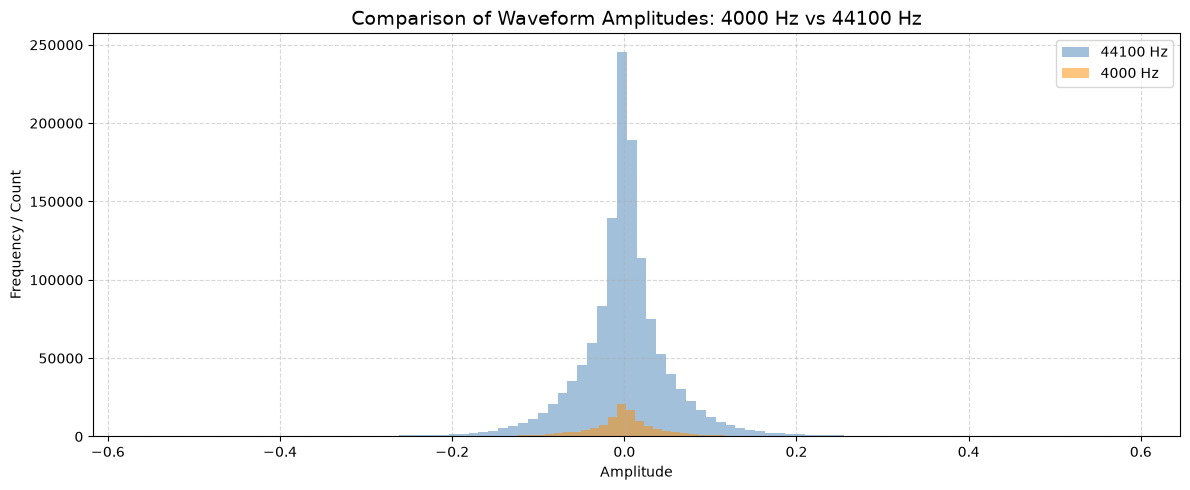

In [5]:
# plot a histogram of the waveform amplitudes at 4000Hz vs 44100 Hz
# Load the audio at both sample rates
y_4k, _ = librosa.load(small['audio_path'].iloc[10], sr=4000)
y_44k, _ = librosa.load(small['audio_path'].iloc[10], sr=44100)

# Plotting the histogram of the waveform amplitudes
plt.figure(figsize=(12, 5))

# Overlaid histograms
plt.hist(y_44k, bins=100, alpha=0.5, label='44100 Hz', color='steelblue', edgecolor='none')
plt.hist(y_4k, bins=100, alpha=0.5, label='4000 Hz', color='darkorange', edgecolor='none')

plt.title('Comparison of Waveform Amplitudes: 4000 Hz vs 44100 Hz', fontsize=14)
plt.xlabel('Amplitude')
plt.ylabel('Frequency / Count')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

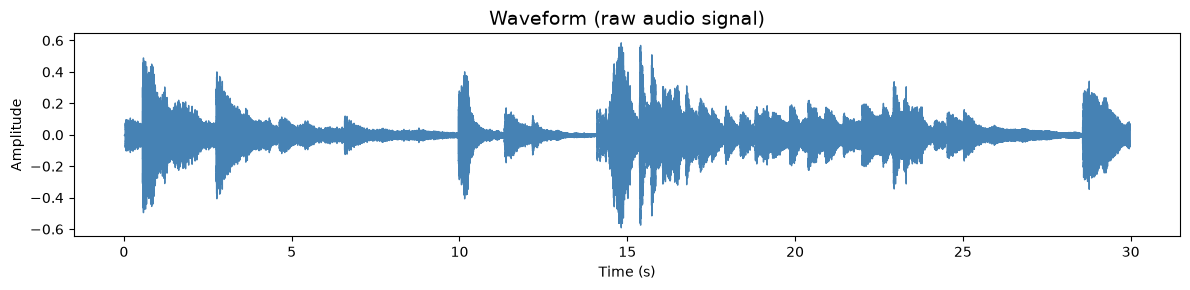

In [6]:
# Display waveform for a single example

plt.figure(figsize=(12, 3))              # create a wide, short figure (12 wide, 3 tall)
librosa.display.waveshow(y, sr=sr, color='steelblue')  # plot amplitude over time
plt.title('Waveform (raw audio signal)', fontsize=14)  # figure title
plt.xlabel('Time (s)')                   # x-axis: time in seconds
plt.ylabel('Amplitude')                  # y-axis: amplitude (-1.0 to +1.0)
plt.tight_layout()                       # remove excess whitespace around the plot
plt.show()      

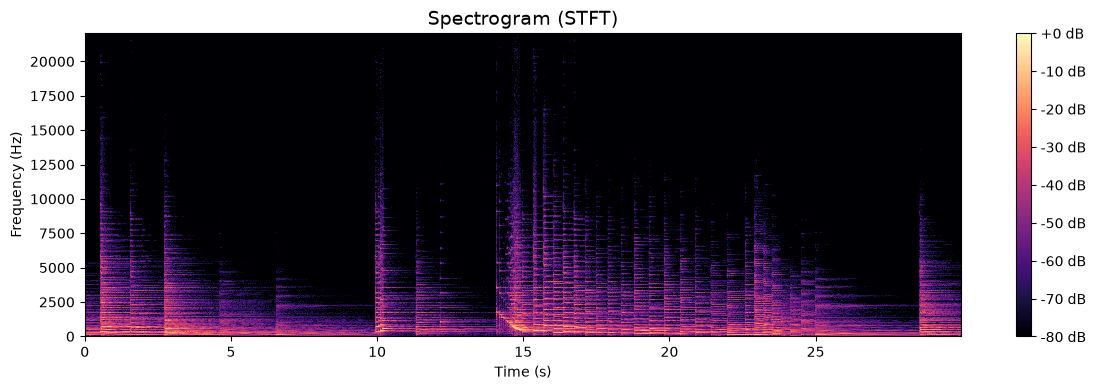

In [7]:
# Compute the Short-Time Fourier Transform (STFT)
# splits the audio into short overlapping windows and computes
# the frequency content of each window
D = librosa.stft(y)

# Convert complex STFT output to decibels (dB) for visualisation
# np.abs(D), magnitude (discard phase information)
# ref=np.max, normalise relative to the loudest frequency (sets the loudest value as 0 dB reference)
D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(D_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')  # plot frequency over time
plt.colorbar(format='%+2.0f dB')        # colour bar showing intensity in decibels
plt.title('Spectrogram (STFT)', fontsize=14)
plt.xlabel('Time (s)')                  # x-axis: time in seconds
plt.ylabel('Frequency (Hz)')            # y-axis: frequency in Hz (linear scale)
plt.tight_layout()
plt.show()

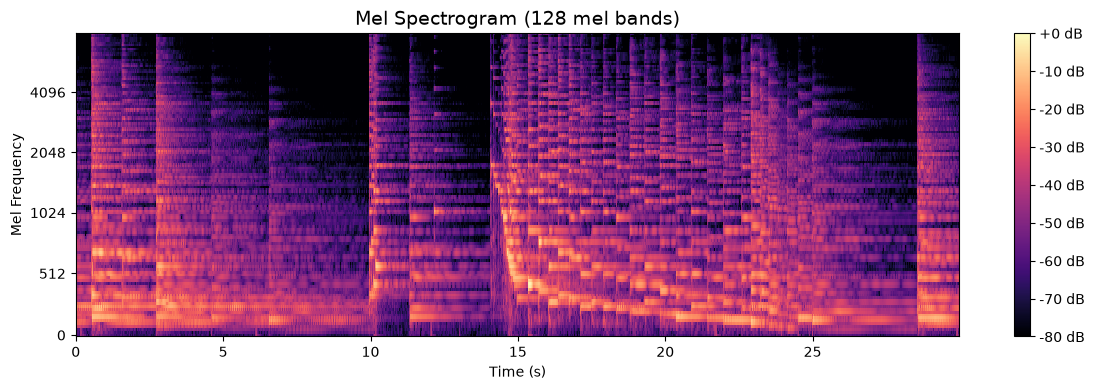

In [8]:
# Compute mel spectrogram
# n_mels=128: number of mel frequency bands (more bands = more frequency detail)
# fmax=8000: only consider frequencies up to 8000 Hz (covers most speech and music)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)

# Convert power to decibels (dB) for visualisation
# power_to_db (vs amplitude_to_db above) because melspectrogram returns power, not amplitude
# ref=np.max, normalise relative to the loudest frequency (0 dB = loudest)
S_db = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', fmax=8000, cmap='magma')  # y_axis='mel' -> perceptual frequency scale
plt.colorbar(format='%+2.0f dB')                                                             # colour bar showing intensity in decibels
plt.title('Mel Spectrogram (128 mel bands)', fontsize=14)
plt.xlabel('Time (s)')
plt.ylabel('Mel Frequency')                                                                  # mel scale: compressed at high frequencies
plt.tight_layout()
plt.show()

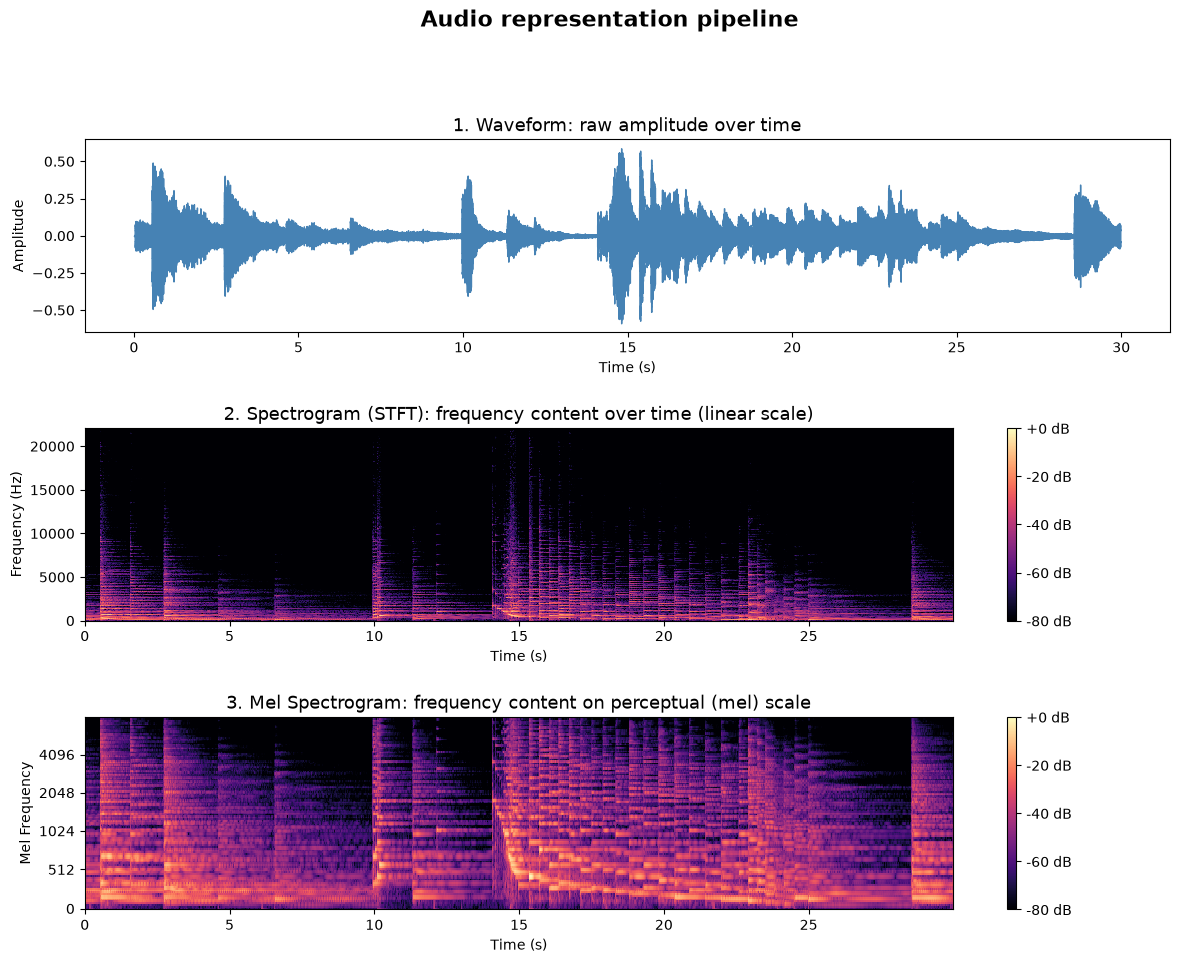

In [9]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 1, hspace=0.5)

# --- Waveform ---
ax1 = fig.add_subplot(gs[0])
librosa.display.waveshow(y, sr=sr, ax=ax1, color='steelblue')
ax1.set_title('1. Waveform: raw amplitude over time', fontsize=13)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')

# --- Spectrogram (STFT) ---
ax2 = fig.add_subplot(gs[1])
img2 = librosa.display.specshow(D_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma', ax=ax2)
fig.colorbar(img2, ax=ax2, format='%+2.0f dB')
ax2.set_title('2. Spectrogram (STFT): frequency content over time (linear scale)', fontsize=13)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Frequency (Hz)')

# --- Mel Spectrogram ---
ax3 = fig.add_subplot(gs[2])
img3 = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', fmax=8000, cmap='magma', ax=ax3)
fig.colorbar(img3, ax=ax3, format='%+2.0f dB')
ax3.set_title('3. Mel Spectrogram: frequency content on perceptual (mel) scale', fontsize=13)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Mel Frequency')

plt.suptitle('Audio representation pipeline', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('audio_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

#### Step 4: Creating Relevant Functions to Convert WAV to Mel Spectogram

In [10]:
def mp3_to_melspec(path):
    # librosa loads MP3 through the installed audio backend
    try:
        y, sr = librosa.load(path, sr=cfg.sr, mono=True)

        if y.size == 0 or not np.isfinite(y).all():
            raise ValueError("Audio is empty or contains non-finite samples.")

        # Also check for complete silence (all zeros) in the audio signal - will remove 1 track (track 107535) from the dataset
        if np.all(y == 0):
            raise ValueError("Audio is completely silent (all zeros).")

        # Measure before padding/truncation
        loaded_duration = len(y) / sr

        # Make every waveform exactly 30 seconds
        y = librosa.util.fix_length(y, size=sr * 30)
    
        # Compute mel spectrogram
        # n_mels=128: number of mel frequency bands (more bands = more frequency detail)
        # fmax=8000: only consider frequencies up to 8000 Hz (covers most speech and music)
        S = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=cfg.n_fft,
            hop_length=cfg.hop_length,
            n_mels=cfg.n_mels,
            fmax=cfg.fmax,
            center=True
        )

        # Convert power to decibels (dB) for visualisation
        # power_to_db (vs amplitude_to_db above) because melspectrogram returns power, not amplitude
        # ref=np.max, normalise relative to the loudest frequency (0 dB = loudest)
        S_db = librosa.power_to_db(S, ref=np.max, top_db=cfg.top_db)

        return y, sr, S, S_db, loaded_duration, None

    except Exception as exc:
        return None, None, None, None, np.nan, str(exc)

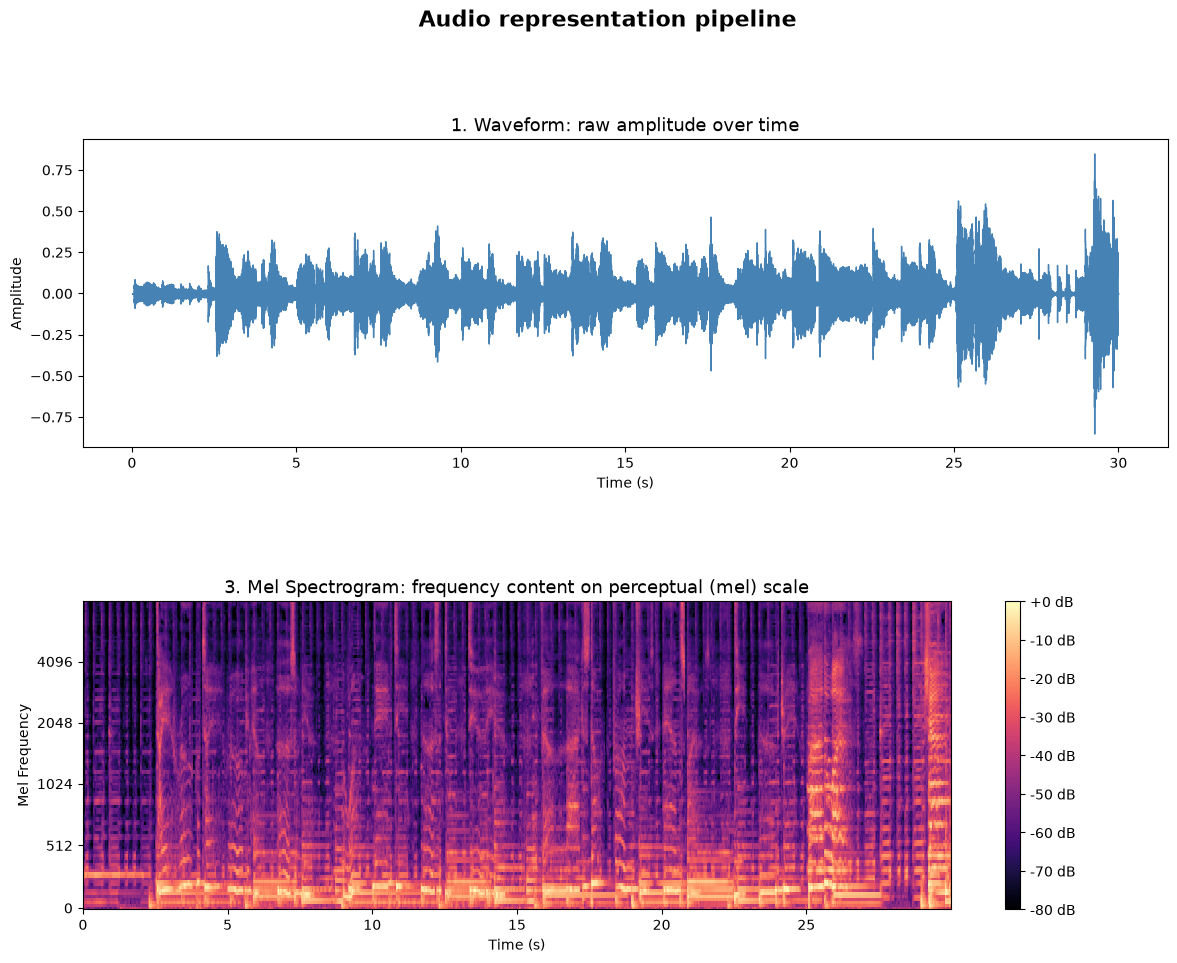

In [ ]:
# Try with one example first to validate function works as intended
first_id = small['audio_path'].iloc[3]
y, sr, S, S_db, loaded_duration, error = mp3_to_melspec(first_id)

if error is not None:
    raise RuntimeError(error)

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 1, hspace=0.5)

# --- Waveform ---
ax1 = fig.add_subplot(gs[0])
librosa.display.waveshow(y, sr=sr, ax=ax1, color='steelblue')
ax1.set_title('1. Waveform: raw amplitude over time', fontsize=13)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')

# --- Mel Spectrogram ---
ax3 = fig.add_subplot(gs[1])
img3 = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', fmax=8000, cmap='magma', ax=ax3)
fig.colorbar(img3, ax=ax3, format='%+2.0f dB')
ax3.set_title('3. Mel Spectrogram: frequency content on perceptual (mel) scale', fontsize=13)
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Mel Frequency')

plt.suptitle('Audio representation pipeline', fontsize=16, fontweight='bold', y=1.01)
plt.show()

#### Step 5: Convert MP3s to Mel Spectogram

In [12]:
selected_ids = (
    small.index[:cfg.max_tracks]
    if cfg.max_tracks is not None
    else small.index
)

results = small.loc[selected_ids, ["genre", "split", "audio_path"]].copy()
results["loaded_duration_seconds"] = np.nan
results["mel_path"] = None
results["conversion_error"] = None
results["status"] = "pending"

cfg.output_dir.mkdir(parents=True, exist_ok=True)
manifest_path = cfg.output_dir / "conversion_results.csv"

# Check if previous manifest exists and load it to resume processing
if manifest_path.is_file():
    previous_results = pd.read_csv(manifest_path, index_col="track_id")
    for col in ["loaded_duration_seconds", "mel_path", "conversion_error", "status"]:
        if col in previous_results.columns:
            results[col] = previous_results[col].reindex(results.index)
    print("Existing manifest found with", len(previous_results), "records.")
    
expected_shape = (
    cfg.n_mels,
    1 + (cfg.sr * 30) // cfg.hop_length
)

total = len(results)
start = perf_counter()

print("Processing, total=", total, " tracks")
print("Output directory:", cfg.output_dir.resolve())

for count, track_id in enumerate(results.index, start=1):
    mel_path = cfg.output_dir / f"{int(track_id):06d}.npy"

    # Check if file already exists and marked successful
    if mel_path.is_file():
        results.at[track_id, "mel_path"] = str(mel_path)
        results.at[track_id, "status"] = "success"
        if pd.isna(results.at[track_id, "loaded_duration_seconds"]):
            results.at[track_id, "loaded_duration_seconds"] = 30.0
        continue
    
    audio_path = results.at[track_id, "audio_path"]

    try:
        y, sr, S, S_db, duration, error = mp3_to_melspec(audio_path)

        if error is not None:
            raise RuntimeError(error)

        results.at[track_id, "loaded_duration_seconds"] = duration
        mel = S_db.astype(np.float32)
        
        if mel.shape != expected_shape:
            raise ValueError(f"Unexpected shape: {mel.shape}")

        if not np.isfinite(mel).all():
            raise ValueError("Spectrogram contains NaN or infinity.")

        mel_path = cfg.output_dir / f"{int(track_id):06d}.npy"
        np.save(mel_path, mel)

        # Verify the file can be read
        saved = np.load(mel_path)

        results.at[track_id, "mel_path"] = str(mel_path)
        results.at[track_id, "status"] = "success"

    except Exception as exc:
        results.at[track_id, "conversion_error"] = str(exc)
        results.at[track_id, "status"] = "failed"

    if count % 100 == 0 or count == total:
        results.to_csv(manifest_path)

        elapsed = perf_counter() - start
        remaining_minutes = (elapsed / count) * (total - count) / 60

        succeeded = (results["status"] == "success").sum()
        failed = (results["status"] == "failed").sum()

        print(
            f"{count}/{total} | "
            f"success={succeeded}, failed={failed} | "
            f"elapsed={elapsed / 60:.1f} min | "
            f"estimated remaining={remaining_minutes:.1f} min"
        )

successful = results["status"] == "success"
failed_results = results.loc[results["status"] == "failed"]

print("Successfully converted:", successful.sum())
print("Failed conversions:", len(failed_results))
print("Expected mel shape:", expected_shape)
print("Max original loaded duration:", results.loc[successful, "loaded_duration_seconds"].max(), "seconds")
print("Min original loaded duration:", results.loc[successful, "loaded_duration_seconds"].min(), "seconds")
print("Saved processing record:", manifest_path)

display(failed_results[["audio_path", "conversion_error"]])

Existing manifest found with 8000 records.
Processing, total= 8000  tracks
Output directory: /Users/mattthomas/GitHub/datasci-207-final-project/data/local/processed_mel
Successfully converted: 7993
Failed conversions: 7
Expected mel shape: (128, 1292)
Max original loaded duration: 30.002721088435376 seconds
Min original loaded duration: 29.964580498866212 seconds
Saved processing record: ../data/local/processed_mel/conversion_results.csv


Note: Illegal Audio-MPEG-Header 0x00000000 at offset 33361.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).
Note: Illegal Audio-MPEG-Header 0x00000000 at offset 22401.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
Note: Illegal Audio-MPEG-Header 0x00000000 at offset 63168.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? D

,audio_path,conversion_error
track_id,,
98565,../data/local/fma_small_mp3/fma_small/098/0985...,Unspecified internal error.
98567,../data/local/fma_small_mp3/fma_small/098/0985...,Unspecified internal error.
98569,../data/local/fma_small_mp3/fma_small/098/0985...,Unspecified internal error.
99134,../data/local/fma_small_mp3/fma_small/099/0991...,Error opening '../data/local/fma_small_mp3/fma...
107535,../data/local/fma_small_mp3/fma_small/107/1075...,Audio is completely silent (all zeros).
108925,../data/local/fma_small_mp3/fma_small/108/1089...,Error opening '../data/local/fma_small_mp3/fma...
133297,../data/local/fma_small_mp3/fma_small/133/1332...,Error opening '../data/local/fma_small_mp3/fma...


In [13]:
results.head()

,genre,split,audio_path,loaded_duration_seconds,mel_path,conversion_error,status
track_id,,,,,,,
2,Hip-Hop,training,../data/local/fma_small_mp3/fma_small/000/0000...,29.976599,../data/local/processed_mel/000002.npy,NaN,success
5,Hip-Hop,training,../data/local/fma_small_mp3/fma_small/000/0000...,30.002721,../data/local/processed_mel/000005.npy,NaN,success
10,Pop,training,../data/local/fma_small_mp3/fma_small/000/0000...,29.976599,../data/local/processed_mel/000010.npy,NaN,success
140,Folk,training,../data/local/fma_small_mp3/fma_small/000/0001...,29.976599,../data/local/processed_mel/000140.npy,NaN,success
141,Folk,training,../data/local/fma_small_mp3/fma_small/000/0001...,29.976599,../data/local/processed_mel/000141.npy,NaN,success


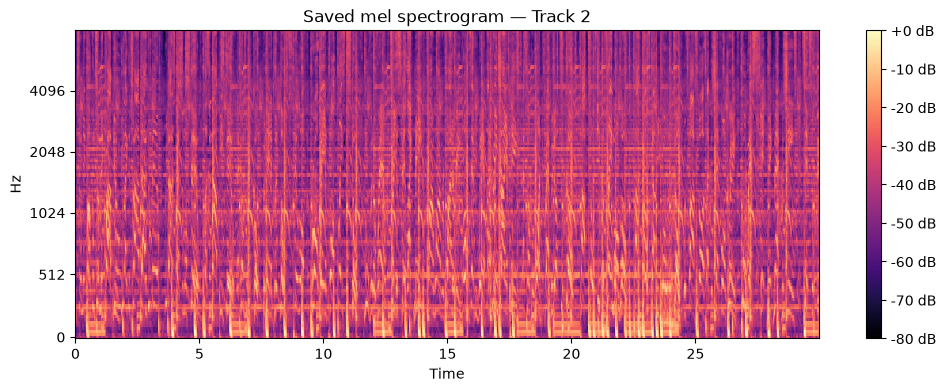

In [14]:
ready_all = results.loc[results["status"] == "success"].copy()
track_id = ready_all.index[0]
mel = np.load(ready_all.at[track_id, "mel_path"])

fig, ax = plt.subplots(figsize=(12, 4))
image = librosa.display.specshow(
    mel,
    sr=cfg.sr,
    hop_length=cfg.hop_length,
    x_axis="time",
    y_axis="mel",
    fmax=cfg.fmax,
    cmap="magma",
    ax=ax
)
fig.colorbar(image, ax=ax, format="%+2.0f dB")
ax.set_title(f"Saved mel spectrogram — Track {track_id}")
plt.show()

In [15]:
# Use successfully converted tracks
ready_all = results.loc[results["status"] == "success"].copy()
ready = ready_all.head(24).copy()

if ready.empty:
    raise ValueError("No successfully converted spectrograms found.")

# Keep one consistent genre mapping across all splits
genre_names = sorted(small["genre"].dropna().unique())
genre_to_id = {
    genre: index
    for index, genre in enumerate(genre_names)
}


def load_mel_image(path):
    mel = np.load(path).astype(np.float32)

    if mel.ndim != 2 or not np.isfinite(mel).all():
        raise ValueError(f"Invalid mel spectrogram: {path}")

    # Assumes power_to_db(ref=np.max, top_db=80)
    image = (np.clip(mel, -80.0, 0.0) + 80.0) / 80.0

    # (mel bands, time frames) -> (mel bands, time frames, 1)
    return image[..., np.newaxis]


X = np.stack([
    load_mel_image(path)
    for path in ready["mel_path"]
])

y_genre = ready["genre"].map(genre_to_id).to_numpy(dtype=np.int64)

print("CNN images:", X.shape)
print("Labels:", y_genre.shape)
print("Value range:", X.min(), "to", X.max())
print("Genre mapping:", genre_to_id)

CNN images: (24, 128, 1292, 1)
Labels: (24,)
Value range: 0.0 to 1.0
Genre mapping: {'Electronic': 0, 'Experimental': 1, 'Folk': 2, 'Hip-Hop': 3, 'Instrumental': 4, 'International': 5, 'Pop': 6, 'Rock': 7}


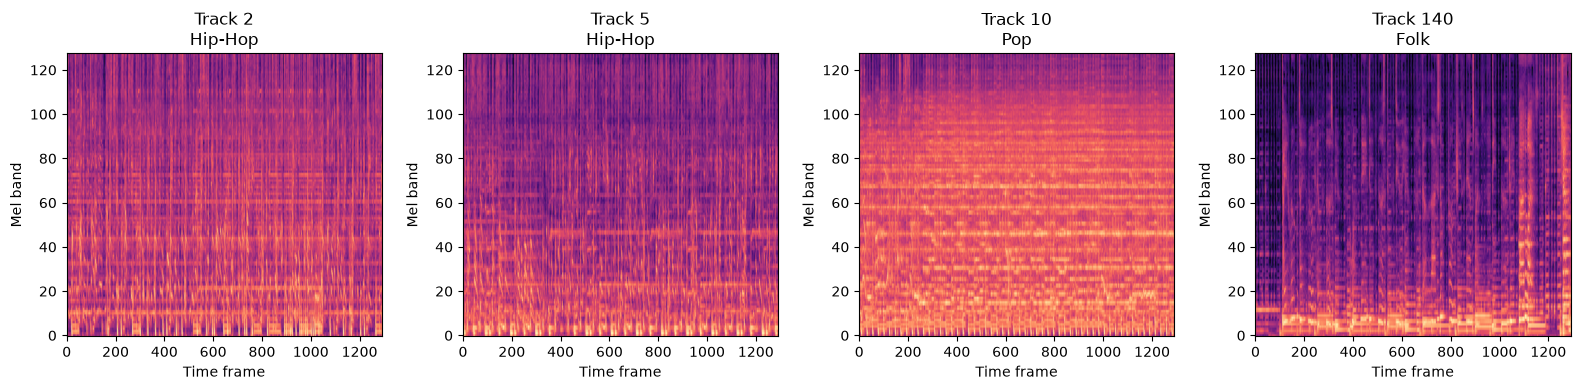

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, ax in enumerate(axes):
    if i >= len(X):
        ax.axis("off")
        continue

    ax.imshow(
        X[i, :, :, 0],
        origin="lower",
        aspect="auto",
        cmap="magma",
        vmin=0,
        vmax=1
    )
    ax.set_title(
        f"Track {ready.index[i]}\n{ready.iloc[i]['genre']}"
    )
    ax.set_xlabel("Time frame")
    ax.set_ylabel("Mel band")

plt.tight_layout()
plt.show()

### Step 6. Additional Checks, Including: Artist Seperation and Spect Dimensions, Amplitudes, and Range.

In [17]:
small_meta = tracks.loc[tracks[("set", "subset")] == "small"].copy()

# Extract artist and album IDs
artist_ids = small_meta[("artist", "id")]
album_ids = small_meta[("album", "id")]
splits = small_meta[("set", "split")]

# Create dfs for artists within each dataset (train, val, test)
train_artists = set(artist_ids[splits == "training"])
val_artists   = set(artist_ids[splits == "validation"])
test_artists  = set(artist_ids[splits == "test"])

# Check for artist intersections across datasets
train_val_artists_leak = train_artists.intersection(val_artists)
train_test_artists_leak = train_artists.intersection(test_artists)
val_test_artists_leak = val_artists.intersection(test_artists)

# Print Results
print("Unique artists - Train:", len(train_artists), "Val:", len(val_artists), "Test:", len(test_artists))
print("Artist overlap Train vs Val:  ", len(train_val_artists_leak))
print("Artist overlap Train vs Test: ", len(train_test_artists_leak))
print("Artist overlap Val vs Test:   ", len(val_test_artists_leak))

# Print final conclusion based on leak results
assert len(train_val_artists_leak) == 0 and len(train_test_artists_leak) == 0 and len(val_test_artists_leak) == 0, \
    "INVESTIGATION NEEDED: Artists overlap across splits."
print("PASS: No artist leakage across splits. The FMA split is artist-conditional.")

# Create dfs for albums within each dataset (train, val, test)
train_albums = set(album_ids[splits == "training"])
val_albums   = set(album_ids[splits == "validation"])
test_albums  = set(album_ids[splits == "test"])

# Check for album intersections across datasets
train_val_album_leak = train_albums.intersection(val_albums)
train_test_album_leak = train_albums.intersection(test_albums)
val_test_album_leak = val_albums.intersection(test_albums)
overlapping_albums = (train_albums & val_albums) | (train_albums & test_albums) | (val_albums & test_albums)

# Print Results
print("Unique albums - Train:", len(train_albums), "Val:", len(val_albums), "Test:", len(test_albums))
print("Album overlap Train vs Val:  ", len(train_val_album_leak))
print("Album overlap Train vs Test: ", len(train_test_album_leak))
print("Album overlap Val vs Test:   ", len(val_test_album_leak))
print("Overlapping albums across splits:", len(overlapping_albums))

# Print final conclusion based on leak results
print("INVESTIGATION NEEDED: 90 Albums overlap across splits. Flagging for deeper analysis via EDA.")

Unique artists - Train: 1888 Val: 219 Test: 202
Artist overlap Train vs Val:   0
Artist overlap Train vs Test:  0
Artist overlap Val vs Test:    0
PASS: No artist leakage across splits. The FMA split is artist-conditional.
Unique albums - Train: 2010 Val: 278 Test: 285
Album overlap Train vs Val:   58
Album overlap Train vs Test:  49
Album overlap Val vs Test:    21
Overlapping albums across splits: 90
INVESTIGATION NEEDED: 90 Albums overlap across splits. Flagging for deeper analysis via EDA.


All shapes match expected (128, 1292): True
All dtypes are float32: True
Any NaNs detected: False
Any Infs detected: False
Max dB across tracks (should be 0.0 dB): 0.0 dB (min: 0.0 dB)
Min dB floor (should be >= -80.0 dB): -80.0 dB
Mean dB range: -77.73517608642578 dB -13.797280311584473 dB


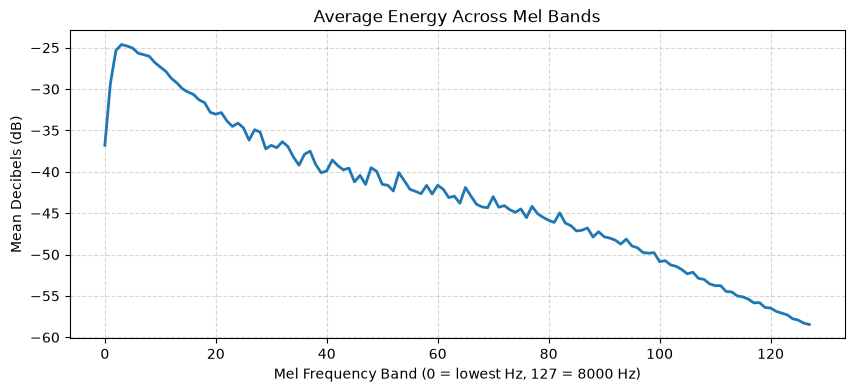

In [18]:
# Pull in successfully loaded mel spectograms
successful_records = results.loc[results["status"] == "success"].copy()

# Create stats frame for compiling
stats = []
mean_mel_energy = np.zeros(cfg.n_mels)
paths = successful_records["mel_path"].tolist()

# For each records, calculate relevant stats from mel spectogram
for path in paths:
    arr = np.load(path)
    mean_mel_energy += arr.mean(axis=1)
    stats.append(
        {
            "shape": arr.shape,
            "dtype": str(arr.dtype),
            "min_db": float(arr.min()),
            "max_db": float(arr.max()),
            "mean_db": float(arr.mean()),
            "std_db": float(arr.std()),
            "has_nan": bool(np.isnan(arr).any()),
            "has_inf": bool(np.isinf(arr).any())
        }
    )

mean_mel_energy /= len(paths)
df_stats = pd.DataFrame(stats)

# Print relevant results
print("All shapes match expected (128, 1292):", (df_stats['shape'] == (128, 1292)).all())
print("All dtypes are float32:", (df_stats['dtype'] == 'float32').all())
print("Any NaNs detected:", df_stats['has_nan'].any())
print("Any Infs detected:", df_stats['has_inf'].any())
print("Max dB across tracks (should be 0.0 dB):", df_stats['max_db'].max(), "dB (min:", df_stats['max_db'].min(), "dB)")
print("Min dB floor (should be >= -80.0 dB):", df_stats['min_db'].min(), "dB")
print("Mean dB range:", df_stats['mean_db'].min(), "dB", df_stats['mean_db'].max(), "dB")

# Calculate and plot mean energy per mel band
plt.figure(figsize=(10, 4))
plt.plot(range(cfg.n_mels), mean_mel_energy, lw=2)
plt.title("Average Energy Across Mel Bands")
plt.xlabel("Mel Frequency Band (0 = lowest Hz, 127 = 8000 Hz)")
plt.ylabel("Mean Decibels (dB)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#### Step 7. Save converted Mel files and split into pre-IDed train, validation, test for EDA and Modeling

In [19]:
if cfg.max_tracks is not None:
    raise RuntimeError(
        "Not creating CSV exports if cfg.max_tracks is set so only a sample runs.", 
        "Set cfg.max_tracks = None to process the full dataset before exporting."
    )

ready_all = results.loc[results["status"] == "success"].copy()

# Create genre integer mapping for modeling
genre_names = sorted(ready_all["genre"].unique())
genre_to_id = {genre: idx for idx, genre in enumerate(genre_names)}
ready_all["genre_id"] = ready_all["genre"].map(genre_to_id)

# Add in artist and album metadata from tracks.csv
ready_all["artist_id"] = small_meta.loc[ready_all.index, ("artist", "id")]
ready_all["artist_name"] = small_meta.loc[ready_all.index, ("artist", "name")]
ready_all["album_id"] = small_meta.loc[ready_all.index, ("album", "id")]
ready_all["album_title"] = small_meta.loc[ready_all.index, ("album", "title")]

# Identify columns to export and tracked path location
cols_to_export = [
    "genre", 
    "genre_id", 
    "mel_path", 
    "artist_id", 
    "artist_name", 
    "album_id", 
    "album_title", 
    "loaded_duration_seconds"
]
tracked_dir = Path("../data/tracked")
tracked_dir.mkdir(parents=True, exist_ok=True)

train_rows = ready_all.loc[ready_all["split"] == "training"].copy()
val_rows = ready_all.loc[ready_all["split"] == "validation"].copy()
test_rows = ready_all.loc[ready_all["split"] == "test"].copy()

print("Training:", len(train_rows))
print("Validation:", len(val_rows))
print("Test:", len(test_rows))

# Save the processed mel spectrograms and metadata to CSV files for each split
for split_name, filename in [
    ("training", "train_mel.csv"),
    ("validation", "val_mel.csv"),
    ("test", "test_mel.csv")
]:
    subset = ready_all.loc[ready_all["split"] == split_name, cols_to_export]
    out_path = tracked_dir / filename
    subset.to_csv(out_path, index_label="track_id")
    print(f"Saved, {filename}: {len(subset)} records -> {out_path}")

# Check how failed conversion affected genre counts
display(pd.crosstab(ready_all["split"], ready_all["genre"]))

# Save Genre Mapping for future reference
genre_mapping_df = pd.DataFrame(
    list(genre_to_id.items()), 
    columns=["genre", "genre_id"]
)
genre_mapping_path = tracked_dir / "genre_mapping.csv"
genre_mapping_df.to_csv(genre_mapping_path, index=False)
print("Saved genre mapping to:", genre_mapping_path)
display(genre_mapping_df)

# Save the failed track IDs and errors for documentation
print("\nFailed conversions:", len(results.loc[results["status"] == "failed"]))
display(
    results.loc[
        results["status"] == "failed",
        ["genre", "split", "conversion_error"]
    ]
)

Training: 6393
Validation: 800
Test: 800
Saved, train_mel.csv: 6393 records -> ../data/tracked/train_mel.csv
Saved, val_mel.csv: 800 records -> ../data/tracked/val_mel.csv
Saved, test_mel.csv: 800 records -> ../data/tracked/test_mel.csv


genre,Electronic,Experimental,Folk,Hip-Hop,Instrumental,International,Pop,Rock
split,,,,,,,,
test,100,100,100,100,100,100,100,100
training,799,799,800,797,799,800,800,799
validation,100,100,100,100,100,100,100,100


Saved genre mapping to: ../data/tracked/genre_mapping.csv


,genre,genre_id
0,Electronic,0
1,Experimental,1
2,Folk,2
3,Hip-Hop,3
4,Instrumental,4
5,International,5
6,Pop,6
7,Rock,7



Failed conversions: 7


,genre,split,conversion_error
track_id,,,
98565,Hip-Hop,training,Unspecified internal error.
98567,Hip-Hop,training,Unspecified internal error.
98569,Hip-Hop,training,Unspecified internal error.
99134,Electronic,training,Error opening '../data/local/fma_small_mp3/fma...
107535,Instrumental,training,Audio is completely silent (all zeros).
108925,Rock,training,Error opening '../data/local/fma_small_mp3/fma...
133297,Experimental,training,Error opening '../data/local/fma_small_mp3/fma...


### Step 8. Create Standardized Image Loading Function for further processing

In [20]:
def load_mel_tensor(npy_path):
    """
    Loads a saved mel spectrogram, normalizes dB [-80, 0] to [0, 1] and adds a channel dimension: (128, 1292, 1).
    """
    mel = np.load(npy_path).astype(np.float32)
    # Normalize to [0, 1]
    normalized = (np.clip(mel, -80.0, 0.0) + 80.0) / 80.0
    return np.expand_dims(normalized, axis=-1)